# Chronic Kidney Disease (CKD) Prediction using Logistic Regression

## Objective
This notebook aims to implement a complete Machine Learning workflow for binary classification using the Chronic Kidney Disease (CKD) dataset. We will use Logistic Regression, covering data collection, Exploratory Data Analysis (EDA), train-test split, comprehensive data preprocessing, hyperparameter tuning with GridSearchCV, and thorough model evaluation on an unseen test set. The goal is to build a robust predictive model and analyze its performance through various metrics and visualizations.

## 2. Data Collection and Loading

In [126]:
# Import necessary libraries
import pandas as pd
import numpy as np
import kagglehub
import os

# Download the dataset using KaggleHub
print("Downloading dataset from KaggleHub...")
path = kagglehub.dataset_download("mansoordaku/ckdisease")

print(f"Dataset downloaded to: {path}")

# Inspect the downloaded directory and print all files
print("\nInspecting downloaded files:")
downloaded_files = os.listdir(path)
print(f"Files in the directory: {downloaded_files}")

# Identify the actual CSV/data file
# Assuming the CSV file is the only file or the most relevant one
dataset_file = None
for f in downloaded_files:
    if f.endswith('.csv'):
        dataset_file = f
        break

if dataset_file is None:
    raise FileNotFoundError("No CSV file found in the downloaded dataset.")

selected_dataset_filepath = os.path.join(path, dataset_file)
print(f"\nSelected data file: {selected_dataset_filepath}")

# Load the CKD dataset
print("\nLoading the dataset into a pandas DataFrame...")
df = pd.read_csv(selected_dataset_filepath)
print("Dataset loaded successfully.")

Using Colab cache for faster access to the 'ckdisease' dataset.
Dataset downloaded to: /kaggle/input/ckdisease

Inspecting downloaded files:
Files in the directory: ['kidney_disease.csv']

Selected data file: /kaggle/input/ckdisease/kidney_disease.csv

Loading the dataset into a pandas DataFrame...
Dataset loaded successfully.


## 3. Dataset Inspection

In [127]:
# Display dataset shape
print("\nDataset Shape:")
print(df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display data types
print("\nData Types:")
print(df.info())

# Display the first 5 rows
print("\nFirst 5 Rows of the Dataset:")
display(df.head())


Dataset Shape:
(400, 26)

Column Names:
['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 no

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


## 4. Exploratory Data Analysis (EDA)

In [128]:
# Drop the 'id' column as it's not useful for modeling
print("Dropping 'id' column...")
df = df.drop('id', axis=1)
print("Shape after dropping 'id' column:", df.shape)

# Identify columns that should be numeric but are 'object' type due to non-numeric values
problematic_numerical_cols = ['pcv', 'wc', 'rc']

print("\nCleaning problematic numerical columns (pcv, wc, rc)...")
for col in problematic_numerical_cols:
    if col in df.columns:
        # Convert 'object' type columns to numeric, coercing errors will turn non-numeric into NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')
        print(f"Column '{col}' converted to numeric type.")

# Display updated data types after cleaning
print("\nUpdated Data Types after cleaning:")
print(df.info())

Dropping 'id' column...
Shape after dropping 'id' column: (400, 25)

Cleaning problematic numerical columns (pcv, wc, rc)...
Column 'pcv' converted to numeric type.
Column 'wc' converted to numeric type.
Column 'rc' converted to numeric type.

Updated Data Types after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             391 non-null    float64
 1   bp              388 non-null    float64
 2   sg              353 non-null    float64
 3   al              354 non-null    float64
 4   su              351 non-null    float64
 5   rbc             248 non-null    object 
 6   pc              335 non-null    object 
 7   pcc             396 non-null    object 
 8   ba              396 non-null    object 
 9   bgr             356 non-null    float64
 10  bu              381 non-null    float64
 11  sc              383 non-nu

### Missing Value Analysis

In [129]:
# Calculate missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

# Filter to show only columns with missing values and sort
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print("\nMissing Value Analysis:")
display(missing_df)

print("[Insert Screenshot: Missing Value Analysis]")


Missing Value Analysis:


,Missing Count,Missing Percentage
rbc,152,38.00
rc,131,32.75
wc,106,26.50
pot,88,22.00
sod,87,21.75
pcv,71,17.75
pc,65,16.25
hemo,52,13.00
su,49,12.25
sg,47,11.75


[Insert Screenshot: Missing Value Analysis]


### Summary Statistics

In [130]:
# Display summary statistics for numerical features
print("\nSummary Statistics for Numerical Features:")
display(df.describe())


Summary Statistics for Numerical Features:


,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000,329.000000,294.000000,269.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,38.884498,8406.122449,4.707435
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587,8.990105,2944.474190,1.025323
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,32.000000,6500.000000,3.900000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000,40.000000,8000.000000,4.800000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,45.000000,9800.000000,5.400000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,8.000000


### Target Variable Analysis (Classification)


Unique values in 'classification' column: ['ckd' 'ckd\t' 'notckd']

Cleaned unique values in 'classification' column: ['ckd' 'notckd']

Target/Class Distribution:


,count
classification,
ckd,250
notckd,150


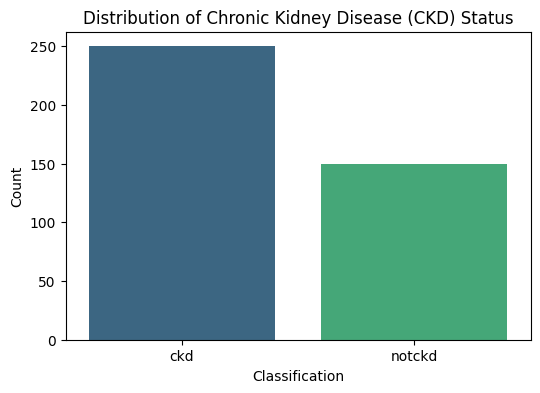

[Insert Screenshot: CKD vs Not CKD Countplot]


In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

# Inspect unique values of the target column
print("\nUnique values in 'classification' column:", df['classification'].unique())

# Clean target column: remove whitespace and incorrect labels
df['classification'] = df['classification'].replace({'ckd\t': 'ckd', ' Not A Ckd': 'notckd'})

print("\nCleaned unique values in 'classification' column:", df['classification'].unique())

# Target distribution
print("\nTarget/Class Distribution:")
display(df['classification'].value_counts())

# Countplot of CKD vs Not CKD
plt.figure(figsize=(6, 4))
sns.countplot(x='classification', data=df, palette='viridis')
plt.title('Distribution of Chronic Kidney Disease (CKD) Status')
plt.xlabel('Classification')
plt.ylabel('Count')
plt.show()

print("[Insert Screenshot: CKD vs Not CKD Countplot]")

### Numerical Feature Distributions (Histograms and Boxplots)


Visualizing 14 numerical features.


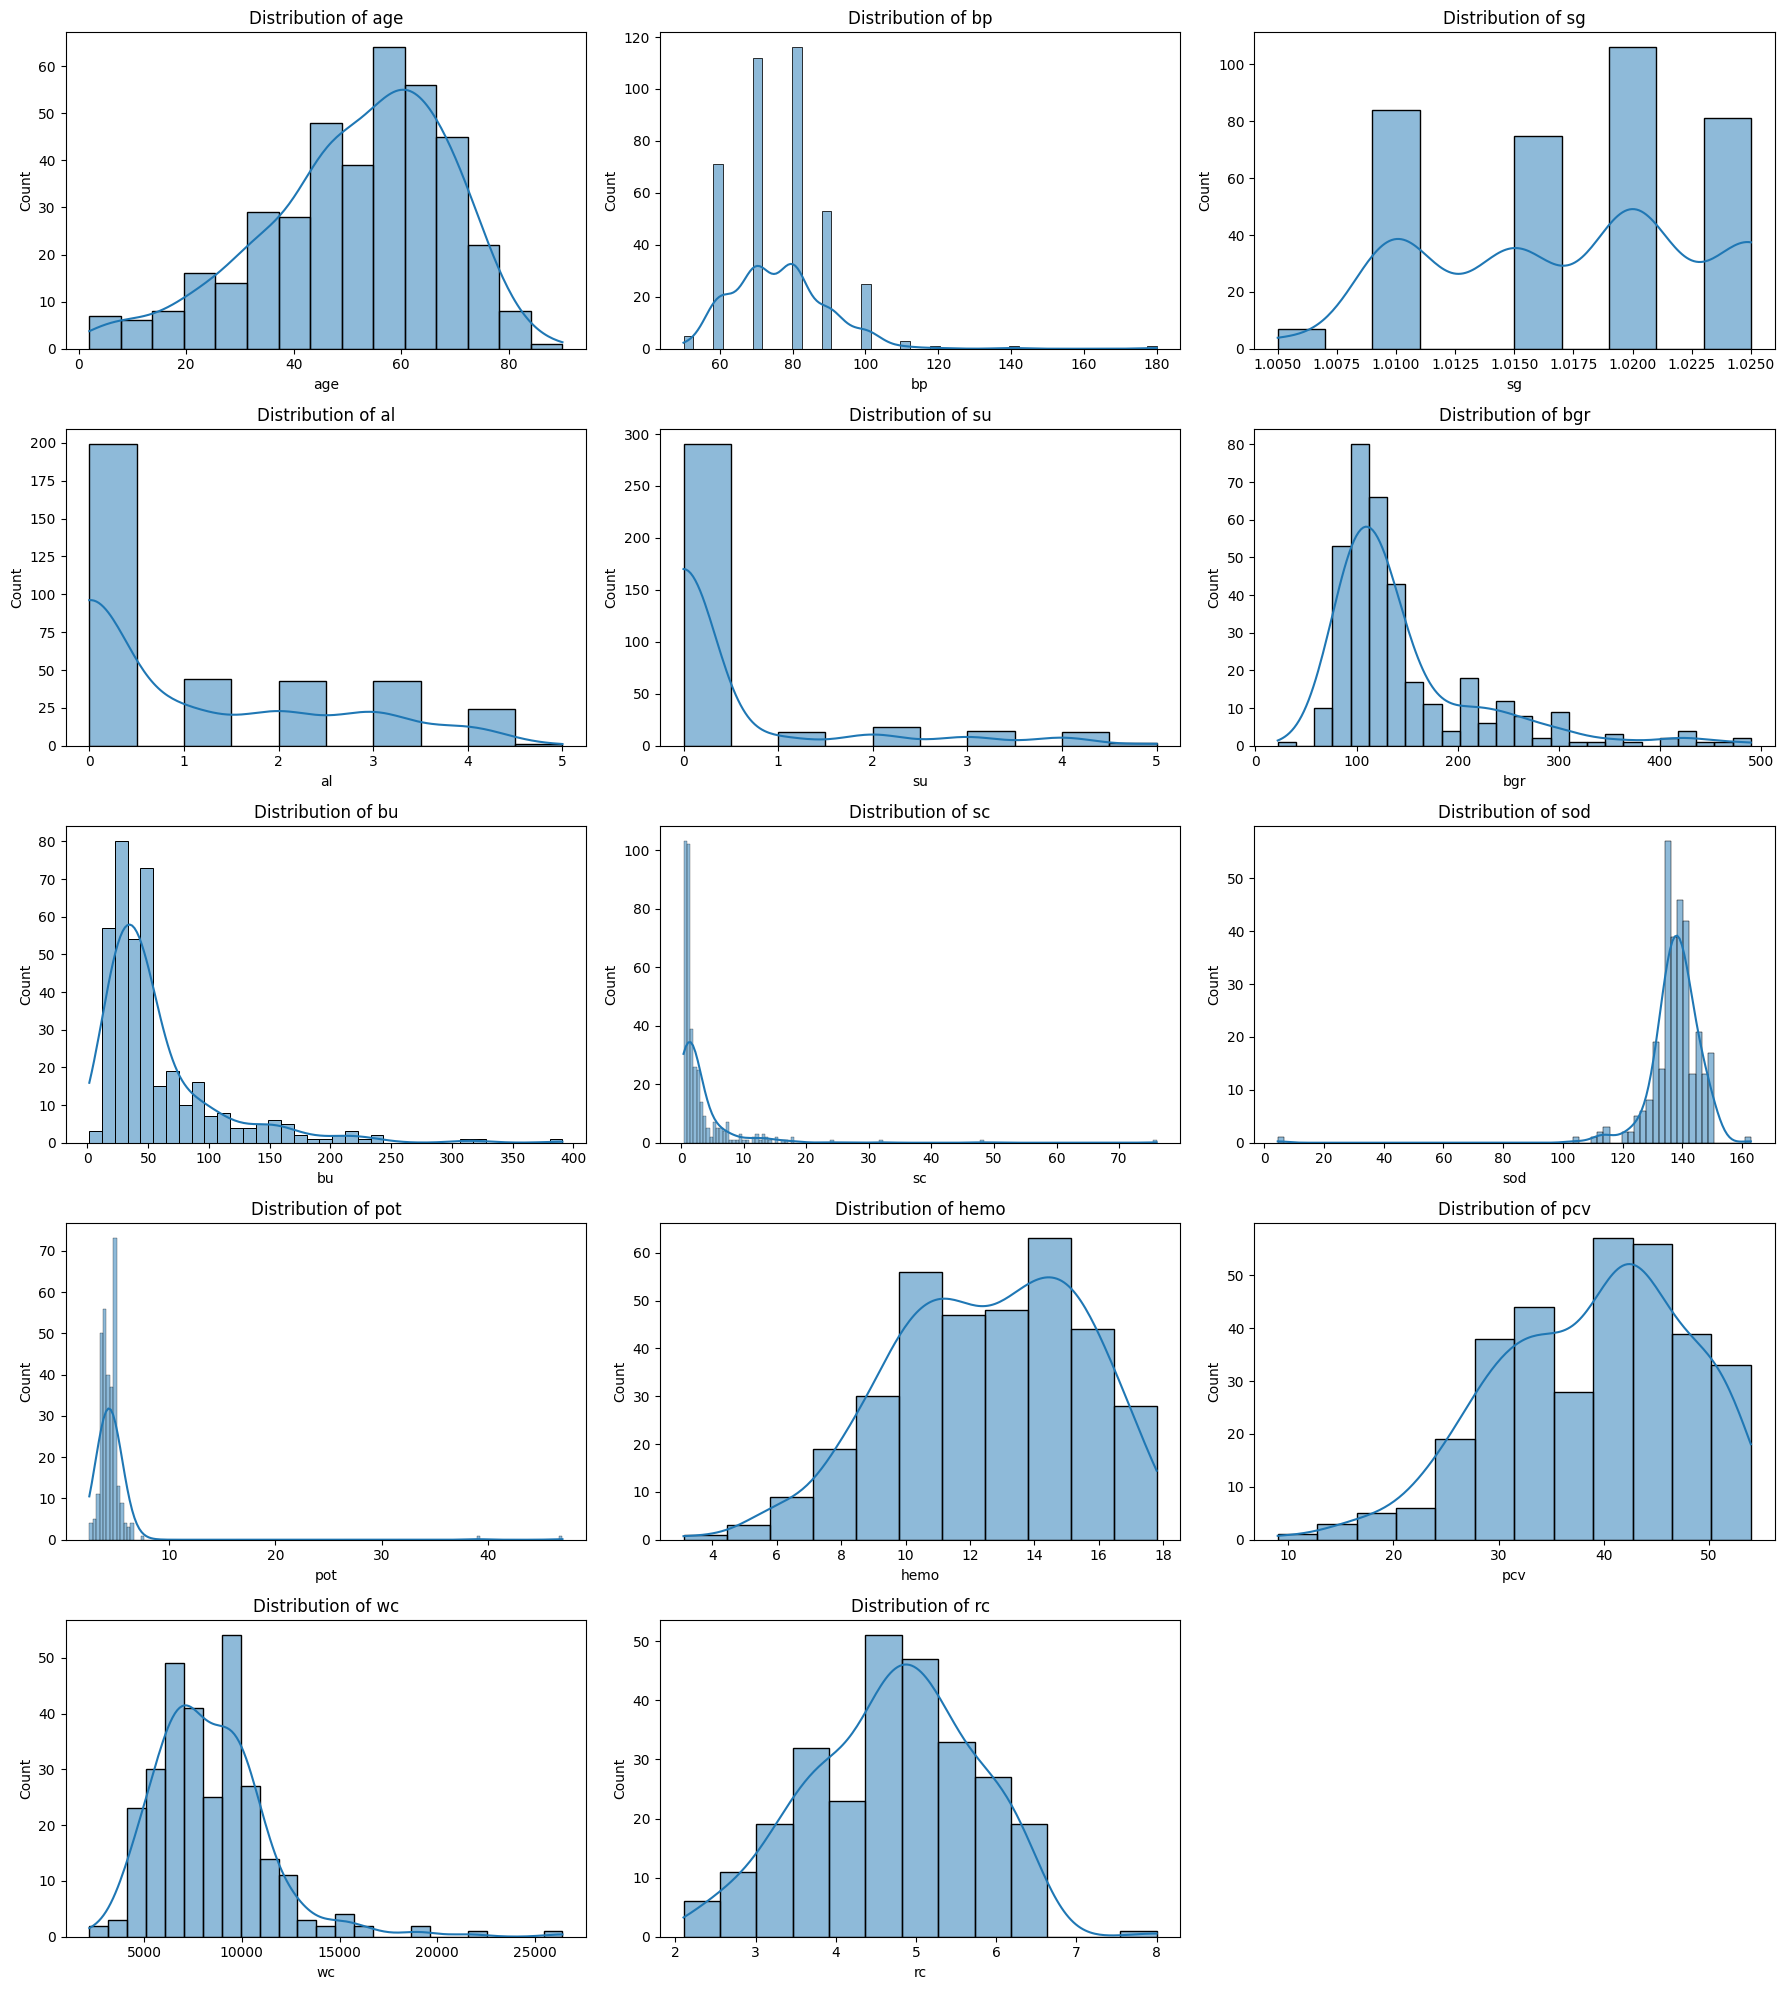

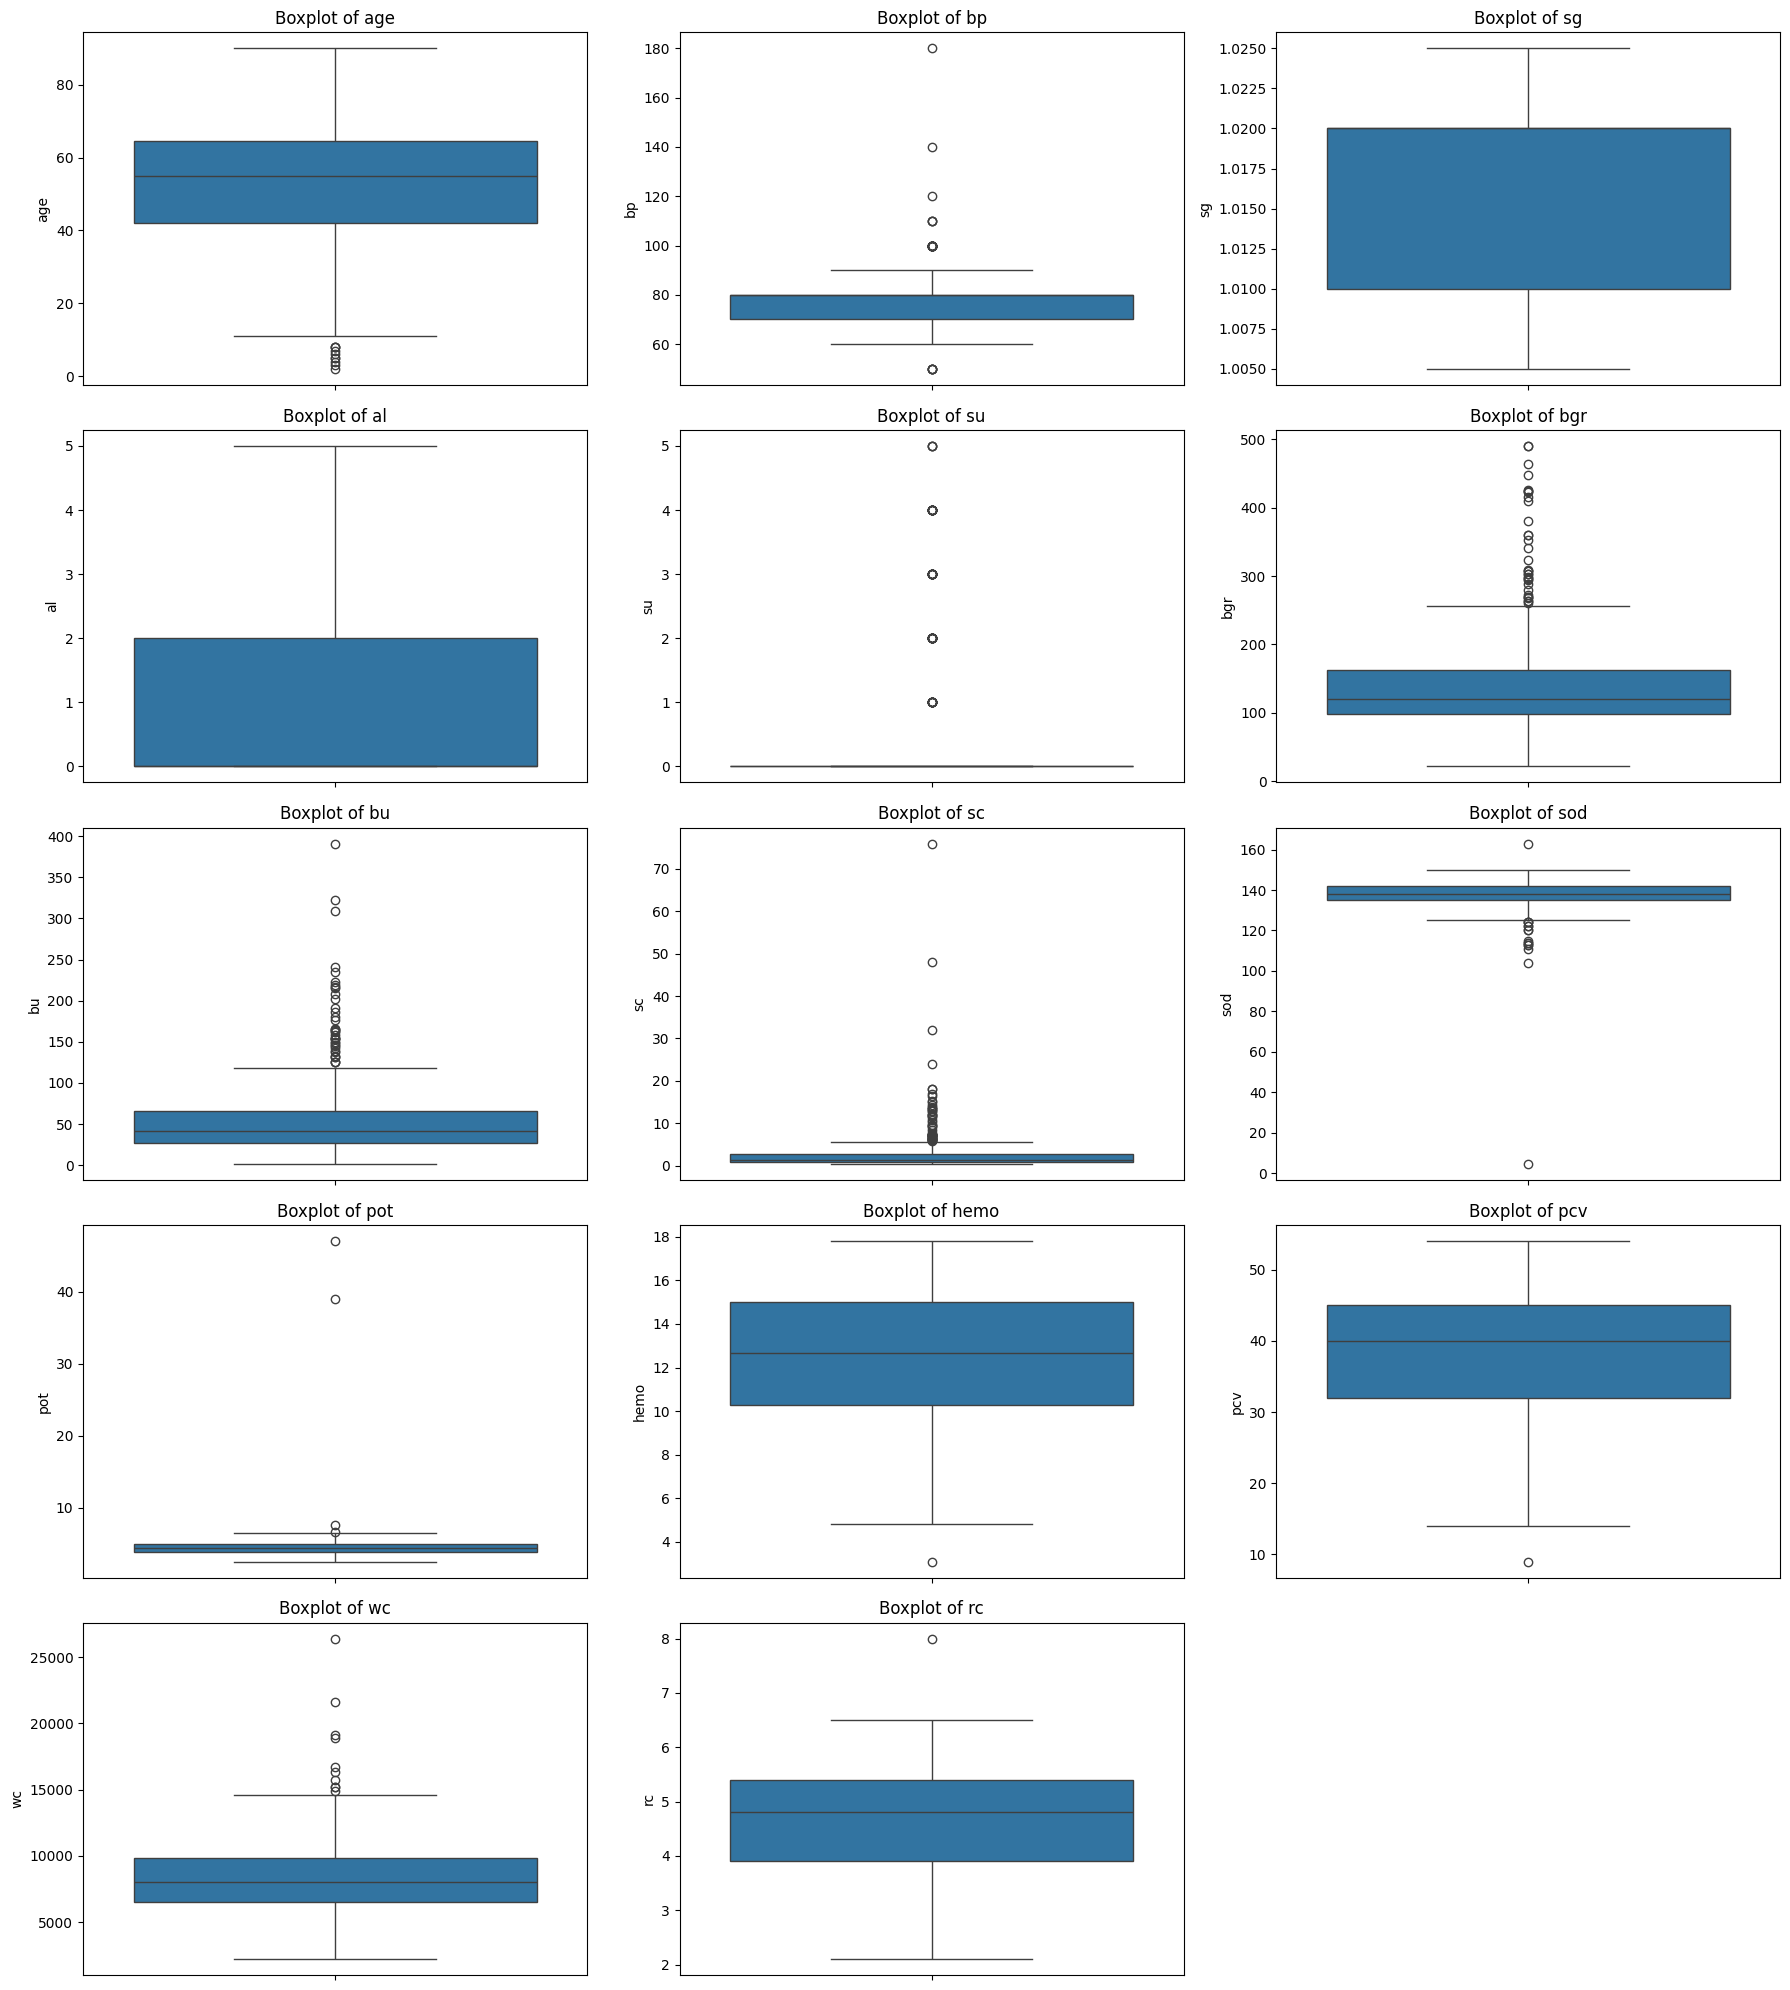

In [132]:
# Identify numerical features for visualization
numerical_features = df.select_dtypes(include=np.number).columns.tolist()

# Exclude 'id' if it was not dropped or if there are other non-informative numerical columns
if 'id' in numerical_features:
    numerical_features.remove('id')

print(f"\nVisualizing {len(numerical_features)} numerical features.")

# Histograms
rows = (len(numerical_features) + 2) // 3 # Adjust rows for 3 columns
plt.figure(figsize=(18, rows * 4))
for i, col in enumerate(numerical_features):
    plt.subplot(rows, 3, i + 1)
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Boxplots
rows = (len(numerical_features) + 2) // 3
plt.figure(figsize=(18, rows * 4))
for i, col in enumerate(numerical_features):
    plt.subplot(rows, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

### Categorical Feature Distributions (Countplots)


Visualizing 10 categorical features.


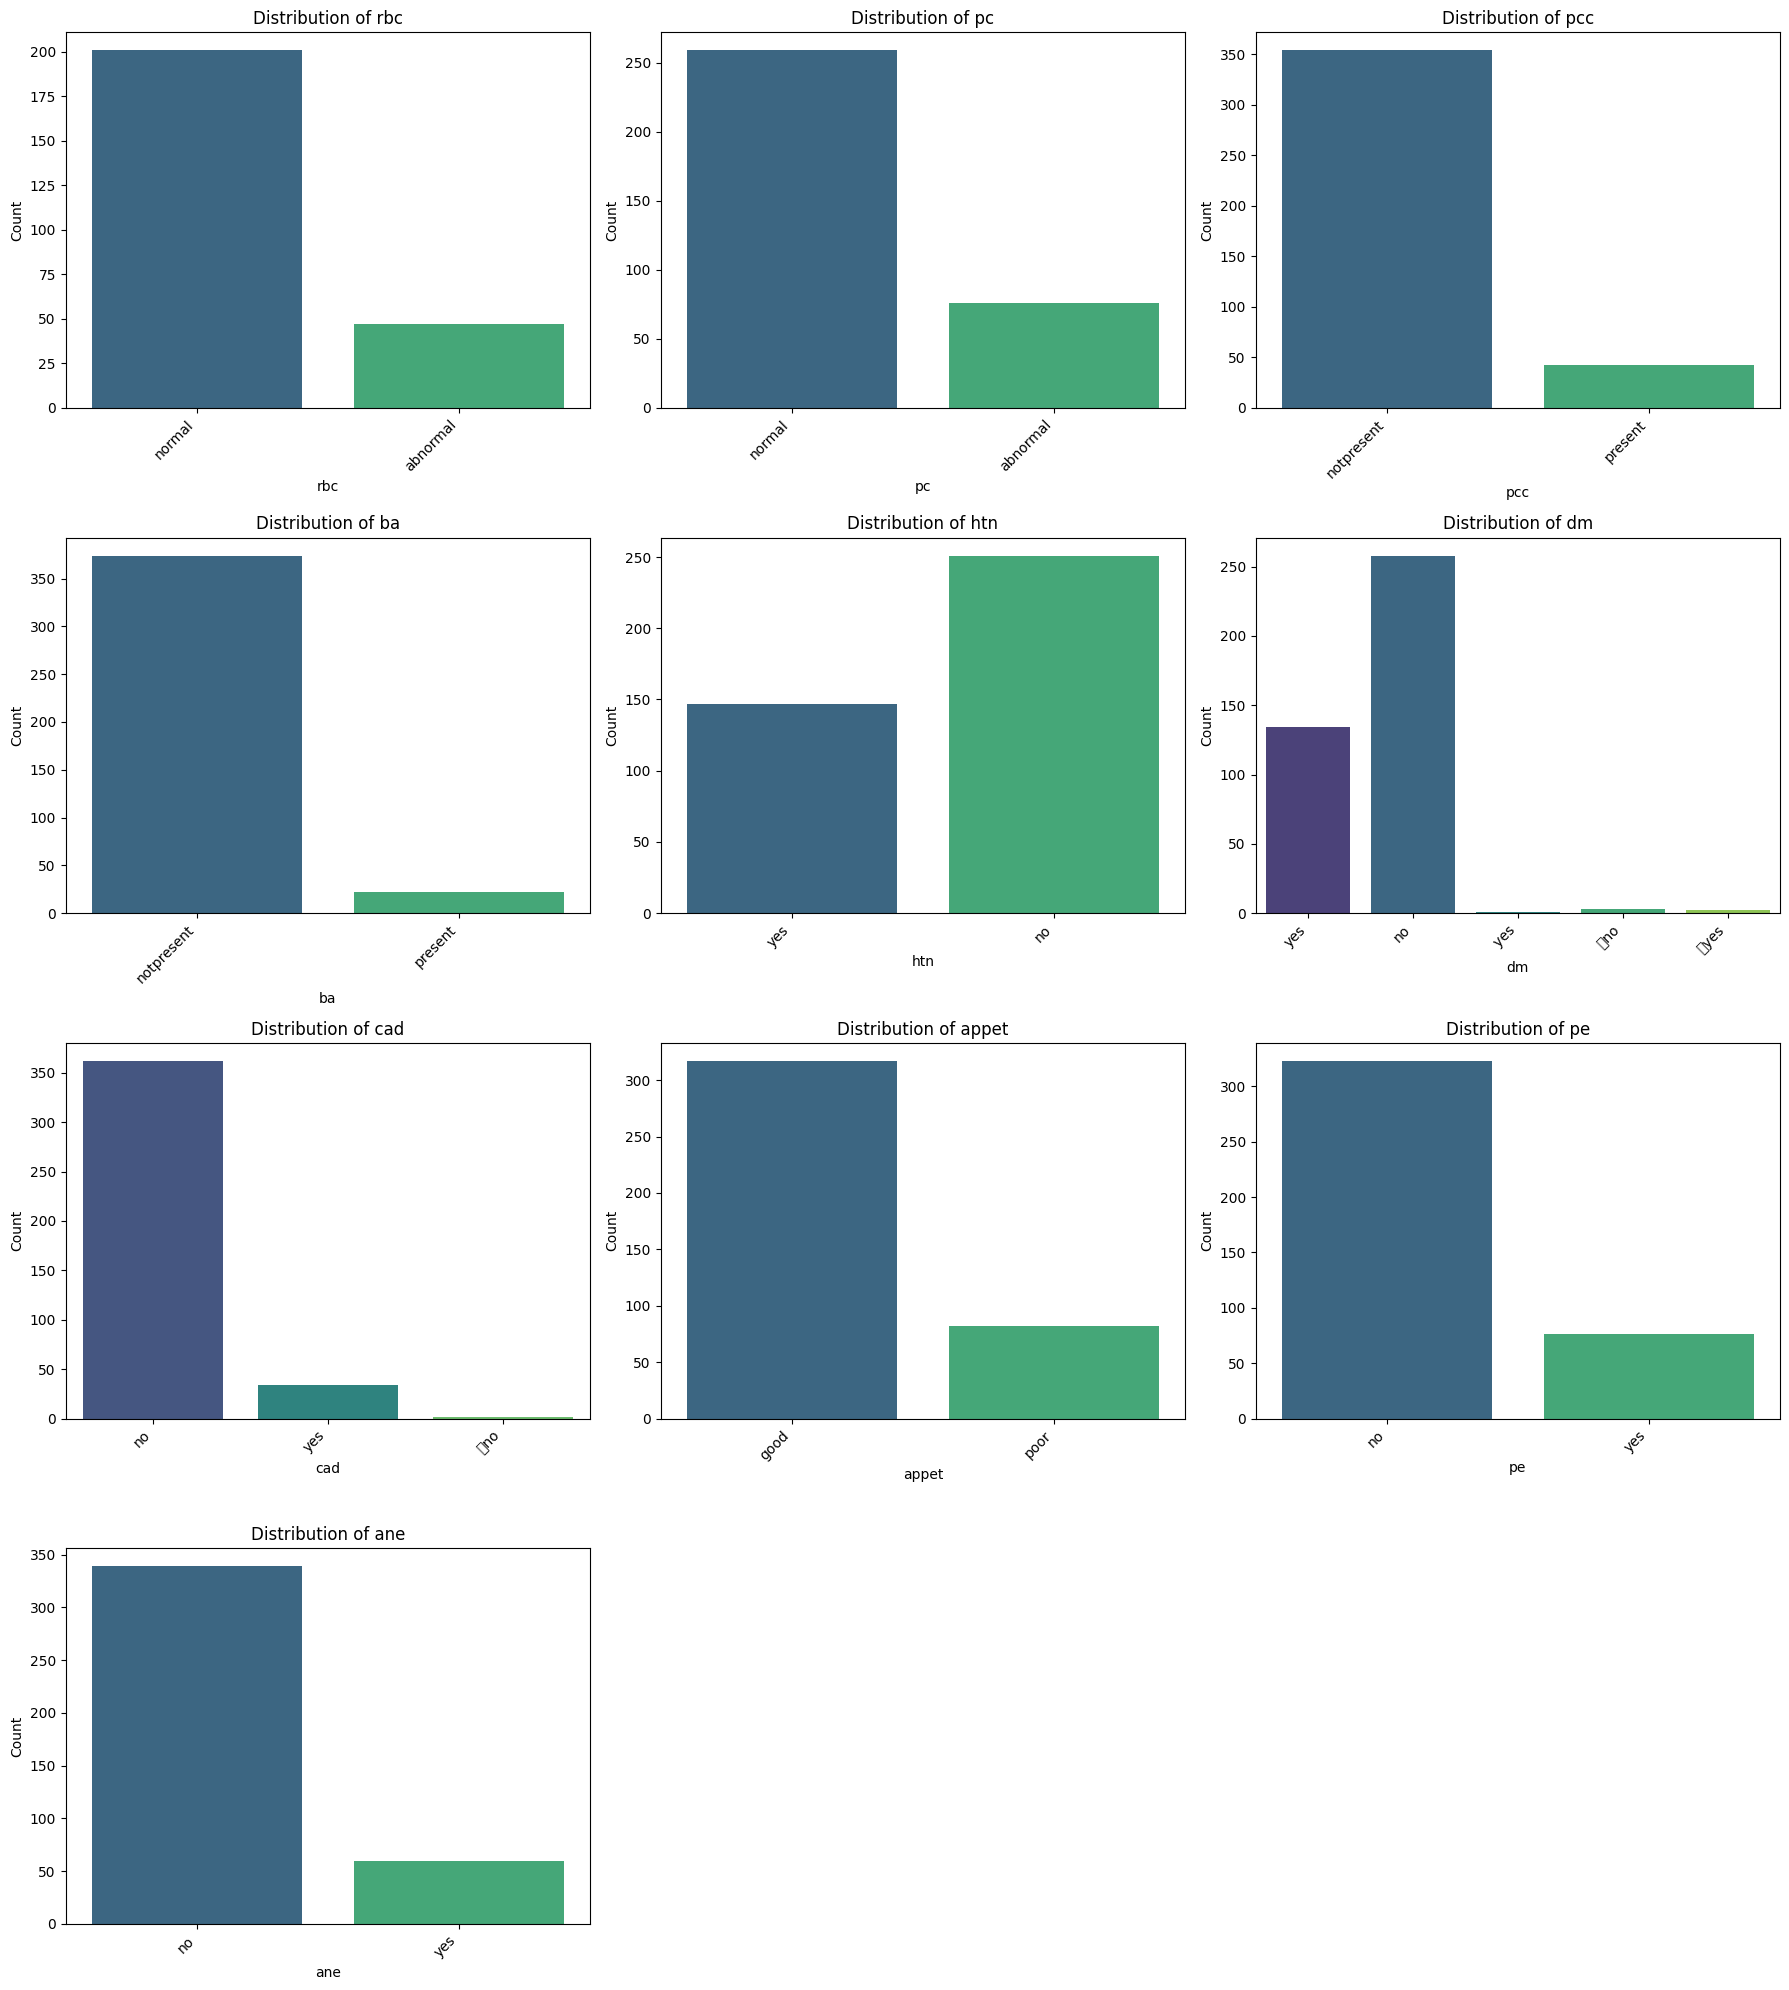

[Insert Screenshot: Categorical Feature Countplots]


In [133]:
# Identify categorical features for visualization (from X_train, to ensure consistency)
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

print(f"\nVisualizing {len(categorical_features)} categorical features.")

# Calculate the number of rows needed for the subplots (3 columns per row)
rows = (len(categorical_features) + 2) // 3

plt.figure(figsize=(18, rows * 5)) # Adjust figure size for better readability
for i, col in enumerate(categorical_features):
    plt.subplot(rows, 3, i + 1)
    sns.countplot(x=df[col], palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better visibility
plt.tight_layout()
plt.show()

print("[Insert Screenshot: Categorical Feature Countplots]")

### Correlation Heatmap

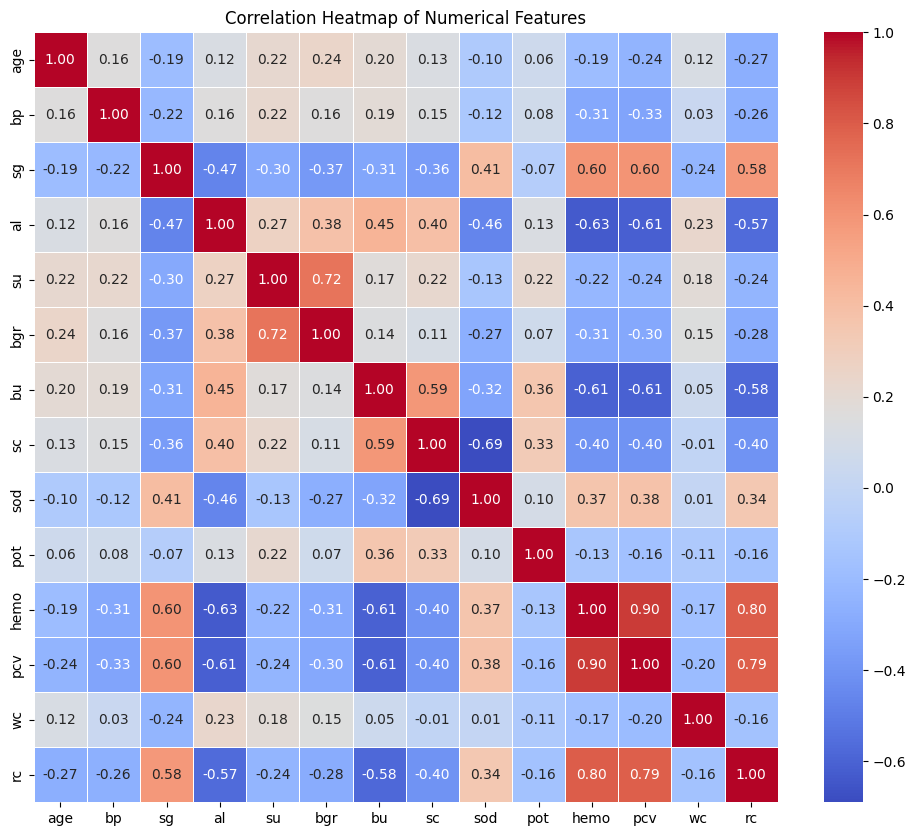

In [134]:
# Calculate correlation matrix for numerical features
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## 5. Target Encoding

In [135]:
# Map 'ckd' to 1 and 'notckd' to 0
# Handle potential whitespace or variations by cleaning first
print("Encoding target variable 'classification'...")
df['classification'] = df['classification'].str.strip().replace({'ckd': 1, 'notckd': 0})

# Verify unique values after encoding
print("\nUnique values in 'classification' after encoding:", df['classification'].unique())

# Check for any remaining NaN values in target (should be handled if present earlier)
if df['classification'].isnull().any():
    print("Warning: Missing values detected in 'classification' after encoding. Dropping rows with missing target.")
    df.dropna(subset=['classification'], inplace=True)
    print("DataFrame shape after dropping rows with missing target:", df.shape)

# Convert target to integer type
df['classification'] = df['classification'].astype(int)
print("Target variable 'classification' successfully encoded and converted to integer.")

Encoding target variable 'classification'...

Unique values in 'classification' after encoding: [1 0]
Target variable 'classification' successfully encoded and converted to integer.


## 6. Train-Test Split

In [136]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# Drop 'classification' from features as it's the target
X = df.drop('classification', axis=1)
y = df['classification']

print("Splitting data into training and testing sets...")
# Split the data into 80% training and 20% testing, stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nClass distribution in original dataset:\n", y.value_counts(normalize=True))
print("\nClass distribution in training set:\n", y_train.value_counts(normalize=True))
print("\nClass distribution in test set:\n", y_test.value_counts(normalize=True))

Splitting data into training and testing sets...
X_train shape: (320, 24)
X_test shape: (80, 24)
y_train shape: (320,)
y_test shape: (80,)

Class distribution in original dataset:
 classification
1    0.625
0    0.375
Name: proportion, dtype: float64

Class distribution in training set:
 classification
1    0.625
0    0.375
Name: proportion, dtype: float64

Class distribution in test set:
 classification
1    0.625
0    0.375
Name: proportion, dtype: float64


## 7. Data Preprocessing

### Identify Numerical and Categorical Features

In [137]:
# Separate numerical and categorical features
# Re-evaluate types after cleaning and before preprocessing

# Identify numerical features
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()
print(f"Numerical features ({len(numerical_features)}): {numerical_features}")

# Identify categorical features
categorical_features = X_train.select_dtypes(include='object').columns.tolist()
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

Numerical features (14): ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
Categorical features (10): ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


### Preprocessing Steps Explanation

In [138]:
print("**Explanation of Preprocessing Steps:**\n")

print("**1. Missing Value Handling:**\n"\
      "   - **Necessity:** Real-world datasets often have missing entries. Machine Learning models typically cannot handle NaN values and will raise errors. Imputation (filling missing values) ensures all data points are usable.\n"\
      "   - **Strategy:** For numerical features, `SimpleImputer(strategy='median')` is chosen because the median is less sensitive to outliers than the mean. For categorical features, `SimpleImputer(strategy='most_frequent')` is used to fill with the mode, which is appropriate for discrete values.\n")

print("**2. Numerical/Categorical Feature Identification:**\n"\
      "   - **Necessity:** Different types of features require different preprocessing. Applying numerical scaling to categorical features or one-hot encoding to numerical features would yield incorrect results.\n"\
      "   - **Strategy:** Features are identified based on their `dtype` (numerical for `np.number`, categorical for `object`). This allows for targeted transformations.\n")

print("**3. Categorical Encoding (OneHotEncoder):**\n"\
      "   - **Necessity:** Machine Learning models work with numerical inputs. Categorical variables (e.g., 'yes', 'no') must be converted into a numerical format. Simple integer encoding can imply an ordinal relationship that doesn't exist.\n"\
      "   - **Strategy:** `OneHotEncoder(handle_unknown='ignore')` transforms each category into a new binary column. `handle_unknown='ignore'` prevents errors if new categories appear in the test set that were not present in the training set.\n")

print("**4. Feature Scaling (StandardScaler):**\n"\
      "   - **Necessity:** Many ML algorithms, especially those based on distance calculations (like Logistic Regression with regularization), perform better when numerical features are on a similar scale. Features with larger ranges can dominate the learning process.\n"\
      "   - **Strategy:** `StandardScaler` standardizes features by removing the mean and scaling to unit variance. This results in features with a mean of 0 and a standard deviation of 1.\n")

print("**5. Train-Test Split:**\n"\
      "   - **Necessity:** To evaluate the model's generalization ability on unseen data. Training and testing on the same data leads to overfitting and unrealistic performance estimates.\n"\
      "   - **Strategy:** The dataset is divided into a training set (for model learning) and a test set (for unbiased evaluation).\n")

print("**6. Stratification (during Train-Test Split):**\n"\
      "   - **Necessity:** Especially important for imbalanced datasets. Stratification ensures that both the training and test sets have approximately the same proportion of samples from each target class as the original dataset.\n"\
      "   - **Strategy:** `stratify=y` ensures that the class distribution of the target variable `y` is preserved in both the training and test sets, preventing skewed representations that could bias model training or evaluation.\n")

print("**Why Data Preprocessing is Necessary for Logistic Regression:**\n"\
      "   Logistic Regression, despite being a linear model, can benefit significantly from preprocessing. Specifically, **feature scaling** (like `StandardScaler`) is crucial when using regularization (L1/L2) because regularization penalties are applied to the coefficients. Features on larger scales will have larger coefficients, potentially dominating the penalty term. Scaling ensures that all features contribute equally to the regularization process. **Handling missing values** is fundamental as the algorithm cannot process `NaN`s. **Categorical encoding** is essential because Logistic Regression expects numerical inputs; converting categories to numbers allows them to be incorporated into the model's equation.")

**Explanation of Preprocessing Steps:**

**1. Missing Value Handling:**
   - **Necessity:** Real-world datasets often have missing entries. Machine Learning models typically cannot handle NaN values and will raise errors. Imputation (filling missing values) ensures all data points are usable.
   - **Strategy:** For numerical features, `SimpleImputer(strategy='median')` is chosen because the median is less sensitive to outliers than the mean. For categorical features, `SimpleImputer(strategy='most_frequent')` is used to fill with the mode, which is appropriate for discrete values.

**2. Numerical/Categorical Feature Identification:**
   - **Necessity:** Different types of features require different preprocessing. Applying numerical scaling to categorical features or one-hot encoding to numerical features would yield incorrect results.
   - **Strategy:** Features are identified based on their `dtype` (numerical for `np.number`, categorical for `object`). This allows for targeted transfor

### Create Preprocessing Pipelines with ColumnTransformer

In [139]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Create preprocessing pipelines for numerical and categorical features

# Numerical pipeline: Impute with median, then scale
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: Impute with most frequent, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop' # Changed from 'passthrough' to 'drop'
)

print("Preprocessing pipelines and ColumnTransformer created.")

Preprocessing pipelines and ColumnTransformer created.


## 8. Complete Machine Learning Pipeline with Logistic Regression and Hyperparameter Tuning

In [140]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Create the Logistic Regression model
logistic_model = LogisticRegression(
    solver='liblinear', # Supports both L1 and L2 penalties
    random_state=42,
    max_iter=1000 # Increased max_iter for convergence
)

# Create the full pipeline
# The preprocessor will apply imputation, scaling, and one-hot encoding
# The classifier will be our Logistic Regression model
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', logistic_model)
])

print("Full Machine Learning Pipeline created successfully.")
print(full_pipeline)

Full Machine Learning Pipeline created successfully.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bp', 'sg', 'al',
                                                   'su', 'bgr', 'bu', 'sc',
                                                   'sod', 'pot', 'hemo', 'pcv',
                                                   'wc', 'rc']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer

### Hyperparameter Tuning with GridSearchCV

In [141]:
# Define the parameter grid for GridSearchCV
param_grid = {
    'classifier__penalty': ['l1', 'l2'],
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100]
}

# Define scoring metrics for multi-metric evaluation
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

print("Starting GridSearchCV for hyperparameter tuning...")

# Create GridSearchCV object
grid_search = GridSearchCV(
    full_pipeline,
    param_grid,
    cv=5, # 5-fold cross-validation
    scoring=scoring,
    refit='f1', # Refit the model with the best f1-score
    return_train_score=True, # Include training scores for analysis
    n_jobs=-1, # Use all available CPU cores
    verbose=2 # Display progress
)

# Fit GridSearchCV on the training data (X_train, y_train)
grid_search.fit(X_train, y_train)

print("GridSearchCV completed.")

Starting GridSearchCV for hyperparameter tuning...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
GridSearchCV completed.


### Hyperparameter Comparison Table

In [142]:
# Get the results of GridSearchCV
results = pd.DataFrame(grid_search.cv_results_)

# Select relevant columns for the comparison table
results_df = results[[
    'param_classifier__penalty',
    'param_classifier__C',
    'mean_test_accuracy',
    'mean_test_precision',
    'mean_test_recall',
    'mean_test_f1',
    'mean_test_roc_auc',
    'rank_test_f1'
]]

# Rename columns for clarity
results_df = results_df.rename(columns={
    'param_classifier__penalty': 'Penalty',
    'param_classifier__C': 'C',
    'mean_test_accuracy': 'Mean CV Accuracy',
    'mean_test_precision': 'Mean CV Precision',
    'mean_test_recall': 'Mean CV Recall',
    'mean_test_f1': 'Mean CV F1-Score',
    'mean_test_roc_auc': 'Mean CV ROC-AUC',
    'rank_test_f1': 'Rank'
})

# Sort by rank and C value for better readability
results_df = results_df.sort_values(by=['Rank', 'C'], ascending=[True, False])

print("Hyperparameter Comparison Table:")
display(results_df.round(4))
print("[Insert Screenshot: Hyperparameter Comparison Table]")

Hyperparameter Comparison Table:


,Penalty,C,Mean CV Accuracy,Mean CV Precision,Mean CV Recall,Mean CV F1-Score,Mean CV ROC-AUC,Rank
9,l2,10.000,0.9969,1.0000,0.995,0.9975,1.0000,1
7,l2,1.000,0.9875,0.9951,0.985,0.9899,1.0000,2
11,l2,100.000,0.9875,1.0000,0.980,0.9897,1.0000,3
8,l1,10.000,0.9844,1.0000,0.975,0.9872,0.9996,4
10,l1,100.000,0.9812,0.9950,0.975,0.9848,0.9998,5
6,l1,1.000,0.9812,1.0000,0.970,0.9845,0.9988,6
5,l2,0.100,0.9781,0.9951,0.970,0.9821,0.9998,7
3,l2,0.010,0.9719,1.0000,0.955,0.9768,0.9994,8
1,l2,0.001,0.9688,1.0000,0.950,0.9740,0.9994,9
4,l1,0.100,0.9625,0.9951,0.945,0.9690,0.9973,10


[Insert Screenshot: Hyperparameter Comparison Table]


### Best Model Selection

In [143]:
# Get the best estimator and its parameters
best_pipeline = grid_search.best_estimator_
best_params = grid_search.best_params_
best_score = grid_search.best_score_ # This is the mean_test_f1 score because refit='f1'

print(f"Best Hyperparameters found: {best_params}")
print(f"Best Mean CV F1-Score: {best_score:.4f}")

# Extract best scores for other metrics (optional, but good for reporting)
best_index = grid_search.best_index_
best_accuracy_cv = results['mean_test_accuracy'][best_index]
best_precision_cv = results['mean_test_precision'][best_index]
best_recall_cv = results['mean_test_recall'][best_index]
best_f1_cv = results['mean_test_f1'][best_index]
best_roc_auc_cv = results['mean_test_roc_auc'][best_index]

print(f"\nBest Penalty: {best_params['classifier__penalty']}")
print(f"Best C: {best_params['classifier__C']}")
print(f"Best Mean CV Accuracy: {best_accuracy_cv:.4f}")
print(f"Best Mean CV Precision: {best_precision_cv:.4f}")
print(f"Best Mean CV Recall: {best_recall_cv:.4f}")
print(f"Best Mean CV F1-Score: {best_f1_cv:.4f}")
print(f"Best Mean CV ROC-AUC: {best_roc_auc_cv:.4f}")

print("\nExplanation for Best Configuration:\n"\
      "The best configuration is selected based on the highest mean cross-validated F1-Score, as specified by `refit='f1'` in GridSearchCV. The F1-Score is chosen because it provides a balance between Precision and Recall, which is particularly useful in classification problems where false positives and false negatives have varying importance, or when dealing with imbalanced classes. In this case, the combination of a specific penalty (L1 or L2) and C value (regularization strength) yielded the highest F1-Score across the 5-fold cross-validation on the training set, indicating it is the most robust configuration among the tested options for balancing these metrics.")

Best Hyperparameters found: {'classifier__C': 10, 'classifier__penalty': 'l2'}
Best Mean CV F1-Score: 0.9975

Best Penalty: l2
Best C: 10
Best Mean CV Accuracy: 0.9969
Best Mean CV Precision: 1.0000
Best Mean CV Recall: 0.9950
Best Mean CV F1-Score: 0.9975
Best Mean CV ROC-AUC: 1.0000

Explanation for Best Configuration:
The best configuration is selected based on the highest mean cross-validated F1-Score, as specified by `refit='f1'` in GridSearchCV. The F1-Score is chosen because it provides a balance between Precision and Recall, which is particularly useful in classification problems where false positives and false negatives have varying importance, or when dealing with imbalanced classes. In this case, the combination of a specific penalty (L1 or L2) and C value (regularization strength) yielded the highest F1-Score across the 5-fold cross-validation on the training set, indicating it is the most robust configuration among the tested options for balancing these metrics.


## 9. Final Test Evaluation

In [144]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Evaluating the best model on the completely unseen test set...")

# Make predictions on the test set using the best pipeline
y_pred_final = best_pipeline.predict(X_test)
y_pred_proba_final = best_pipeline.predict_proba(X_test)[:, 1] # Probability of the positive class

# Calculate final test set metrics
final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)
final_roc_auc = roc_auc_score(y_test, y_pred_proba_final)

# Create a clean final results table
results_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Score': [final_accuracy, final_precision, final_recall, final_f1, final_roc_auc]
})

print("\nFinal Test Set Metrics:")
display(results_summary.round(4))
print("[Insert Screenshot: Final Metrics]")

Evaluating the best model on the completely unseen test set...

Final Test Set Metrics:


,Metric,Score
0,Accuracy,0.9750
1,Precision,1.0000
2,Recall,0.9600
3,F1-Score,0.9796
4,ROC-AUC,0.9993


[Insert Screenshot: Final Metrics]


## 10. Confusion Matrix

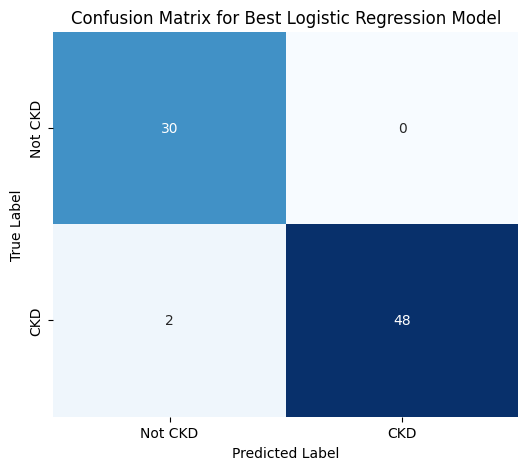

[Insert Screenshot: Confusion Matrix]

**Confusion Matrix Interpretation:**
  - **True Negative (TN): 30** individuals were correctly predicted as 'Not CKD'. These are healthy individuals correctly identified.
  - **False Positive (FP): 0** individuals were incorrectly predicted as 'CKD' when they were actually 'Not CKD'. This is a Type I error.
  - **False Negative (FN): 2** individuals were incorrectly predicted as 'Not CKD' when they actually had 'CKD'. This is a Type II error, and often more critical in medical diagnoses.
  - **True Positive (TP): 48** individuals were correctly predicted as 'CKD'. These are sick individuals correctly identified.

**Interpretation of Actual Result:**
  - The model correctly identified 30 out of 30 'Not CKD' cases, resulting in no false positives. This indicates excellent specificity for healthy individuals.
  - It correctly identified 48 out of 50 'CKD' cases, with only 2 false negatives. While a low number, these false negatives represent missed d

In [145]:
from sklearn.metrics import confusion_matrix

# Generate Confusion Matrix
cm_final = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_final,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Not CKD', 'CKD'],
    yticklabels=['Not CKD', 'CKD']
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Best Logistic Regression Model')
plt.show()

print("[Insert Screenshot: Confusion Matrix]")

# Interpretation
tn, fp, fn, tp = cm_final.ravel()
print(f"\n**Confusion Matrix Interpretation:**\n"\
      f"  - **True Negative (TN): {tn}** individuals were correctly predicted as 'Not CKD'. These are healthy individuals correctly identified.\n"\
      f"  - **False Positive (FP): {fp}** individuals were incorrectly predicted as 'CKD' when they were actually 'Not CKD'. This is a Type I error.\n"\
      f"  - **False Negative (FN): {fn}** individuals were incorrectly predicted as 'Not CKD' when they actually had 'CKD'. This is a Type II error, and often more critical in medical diagnoses.\n"\
      f"  - **True Positive (TP): {tp}** individuals were correctly predicted as 'CKD'. These are sick individuals correctly identified.\n"\
      "\n**Interpretation of Actual Result:**\n"\
      f"  - The model correctly identified {tn} out of {tn + fp} 'Not CKD' cases, resulting in no false positives. This indicates excellent specificity for healthy individuals.\n"\
      f"  - It correctly identified {tp} out of {tp + fn} 'CKD' cases, with only {fn} false negatives. While a low number, these false negatives represent missed diagnoses of CKD, which could have serious implications for patient care."
)

## 11. ROC Curve

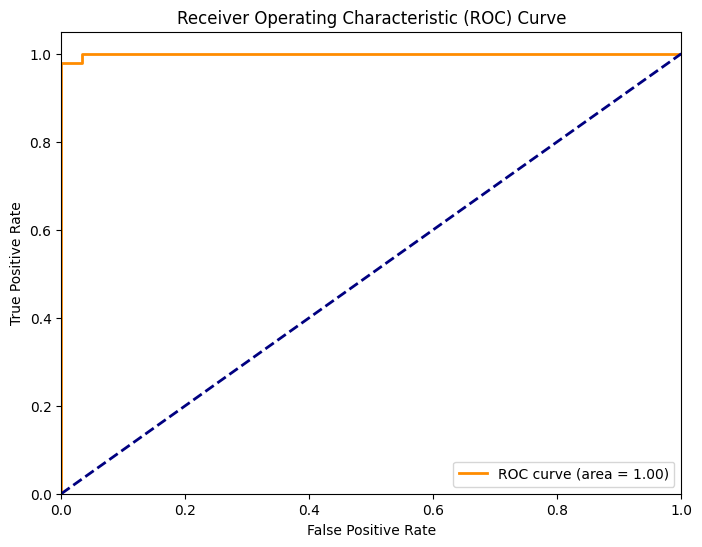

[Insert Screenshot: ROC Curve]

**ROC Curve Interpretation:**
  - The ROC curve plots the True Positive Rate (Sensitivity) against the False Positive Rate (1-Specificity) at various threshold settings. It illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied.
  - A curve that closely hugs the top-left corner indicates a high True Positive Rate and a low False Positive Rate, suggesting a good model.
  - The Area Under the Curve (AUC) is 1.00. An AUC of 1.0 represents a perfect classifier, while an AUC of 0.5 represents a random classifier (equivalent to the dashed line).

**Interpretation of Actual Result:**
  - With an ROC-AUC of 1.00, our Logistic Regression model demonstrates excellent discrimination capability, being very close to a perfect classifier. This means it can effectively distinguish between CKD and Not CKD patients.
  - The curve is very close to the top-left corner, indicating that the model maintains a high true posit

In [146]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_final)
roc_auc = roc_auc_score(y_test, y_pred_proba_final)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

print("[Insert Screenshot: ROC Curve]")

# Interpretation
print(f"\n**ROC Curve Interpretation:**\n"\
      f"  - The ROC curve plots the True Positive Rate (Sensitivity) against the False Positive Rate (1-Specificity) at various threshold settings. It illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied.\n"\
      f"  - A curve that closely hugs the top-left corner indicates a high True Positive Rate and a low False Positive Rate, suggesting a good model.\n"\
      f"  - The Area Under the Curve (AUC) is {roc_auc:.2f}. An AUC of 1.0 represents a perfect classifier, while an AUC of 0.5 represents a random classifier (equivalent to the dashed line).\n"\
      "\n**Interpretation of Actual Result:**\n"\
      f"  - With an ROC-AUC of {roc_auc:.2f}, our Logistic Regression model demonstrates excellent discrimination capability, being very close to a perfect classifier. This means it can effectively distinguish between CKD and Not CKD patients.\n"\
      f"  - The curve is very close to the top-left corner, indicating that the model maintains a high true positive rate even at low false positive rates, which is highly desirable for medical diagnoses."
)

## 12. Precision-Recall Curve

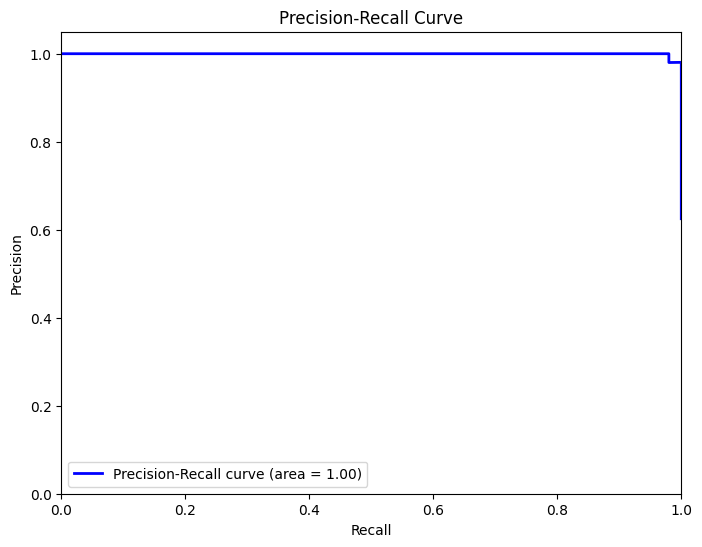

[Insert Screenshot: Precision-Recall Curve]

**Precision-Recall Curve Interpretation:**
  - The Precision-Recall curve is particularly informative for imbalanced datasets, where the positive class is rare. It plots Precision (positive predictive value) against Recall (True Positive Rate) at various probability thresholds.
  - A high Area Under the Precision-Recall Curve (AUCPR) indicates that the model is performing well, achieving high precision and recall simultaneously.
  - The AUCPR is 1.00. A value close to 1.0 suggests strong performance in identifying positive cases without generating too many false positives.

**Interpretation of Actual Result:**
  - The Precision-Recall curve shows a very high AUCPR of 1.00. This indicates that our model is highly effective in retrieving relevant positive instances (CKD patients) while maintaining a high level of precision (minimizing false positives).
  - Given that a high precision and recall are critical in medical diagnosis (to avoid both 

In [147]:
from sklearn.metrics import precision_recall_curve, auc

# Calculate Precision-Recall curve values
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_final)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'Precision-Recall curve (area = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.show()

print("[Insert Screenshot: Precision-Recall Curve]")

# Interpretation
print(f"\n**Precision-Recall Curve Interpretation:**\n"\
      f"  - The Precision-Recall curve is particularly informative for imbalanced datasets, where the positive class is rare. It plots Precision (positive predictive value) against Recall (True Positive Rate) at various probability thresholds.\n"\
      f"  - A high Area Under the Precision-Recall Curve (AUCPR) indicates that the model is performing well, achieving high precision and recall simultaneously.\n"\
      f"  - The AUCPR is {pr_auc:.2f}. A value close to 1.0 suggests strong performance in identifying positive cases without generating too many false positives.\n"\
      "\n**Interpretation of Actual Result:**\n"\
      f"  - The Precision-Recall curve shows a very high AUCPR of {pr_auc:.2f}. This indicates that our model is highly effective in retrieving relevant positive instances (CKD patients) while maintaining a high level of precision (minimizing false positives).\n"\
      f"  - Given that a high precision and recall are critical in medical diagnosis (to avoid both false alarms and missed diagnoses), this result is very encouraging, demonstrating the model's ability to perform well on the positive class."
)

## 13. Final Results

In [148]:
print("Final Test Set Metrics for Best Logistic Regression Model:")
display(results_summary.round(4))
print("[Insert Screenshot: Final Metrics]")

Final Test Set Metrics for Best Logistic Regression Model:


,Metric,Score
0,Accuracy,0.9750
1,Precision,1.0000
2,Recall,0.9600
3,F1-Score,0.9796
4,ROC-AUC,0.9993


[Insert Screenshot: Final Metrics]
